In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import infercnvpy as cnv
import matplotlib.pyplot as plt

In [ ]:
import re
def get_attr(s, key):
    m = re.search(rf'{key}\s+"([^"]+)"', str(s))
    return m.group(1) if m else None

In [ ]:
adata = sc.read_h5ad("h5ad/islet_final_annotated.h5ad")
adata = adata.raw.to_adata()

In [11]:
adata.X.max()

14282.0

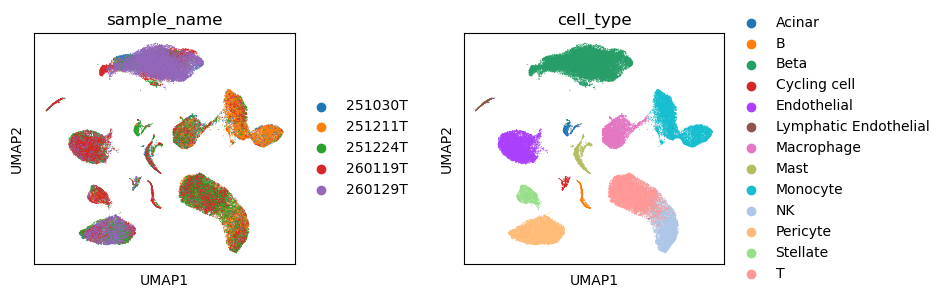

In [5]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata,color=['sample_name','cell_type'],wspace=0.5)

In [23]:
gtf = pd.read_csv(
    "utiils/hg38.gtf",   # 你改成的新路径
    sep="\t",
    comment="#",
    header=None,
    names=["chr","source","feature","start","end","score","strand","frame","attr"]
)


gene = gtf[gtf["feature"] == "gene"].copy()

# GTF 常用 gene_name；没有就回退到 gene_id
gene["gene_name"] = gene["attr"].map(lambda x: get_attr(x, "gene_name"))
gene["gene_id"]   = gene["attr"].map(lambda x: get_attr(x, "gene_id"))
gene["symbol"] = gene["gene_name"].fillna(gene["gene_id"])

gene = gene.dropna(subset=["symbol"]).drop_duplicates("symbol")
gene = gene.set_index("symbol")[["chr", "start", "end"]]

# 染色体名规范化（可选，但推荐）
gene["chr"] = gene["chr"].astype(str)
gene["chr"] = np.where(gene["chr"].str.startswith("chr"), gene["chr"], "chr" + gene["chr"])



In [25]:
# 对齐到表达矩阵基因
adata_cnv = adata.copy()
coords = gene.reindex(adata_cnv.var_names)
adata_cnv.var["chromosome"] = coords["chr"].values
adata_cnv.var["start"] = coords["start"].values
adata_cnv.var["end"] = coords["end"].values

# 保留有坐标且为常规染色体的基因
ok = (
    adata_cnv.var["chromosome"].notna()
    & adata_cnv.var["start"].notna()
    & adata_cnv.var["end"].notna()
)


In [27]:
adata_cnv.var

,chromosome,start,end
AL627309.1,chr1,89295.0,133723.0
AL627309.5,chr1,141474.0,173862.0
AL627309.4,chr1,160446.0,161525.0
AP006222.2,chr1,266855.0,268655.0
AL732372.1,chr1,358857.0,366052.0
...,...,...,...
AC240274.1,chrKI270711.1,4612.0,29626.0
AC004556.3,chrKI270721.1,2585.0,11802.0
AC233755.2,chrKI270726.1,26241.0,26534.0
AC007325.4,chrKI270734.1,131494.0,137392.0


In [28]:
adata_cnv = adata_cnv[:, ok].copy()
adata_cnv = adata_cnv[:, adata_cnv.var["chromosome"].astype(str).str.match(r"^chr([0-9]+|X|Y)$")].copy()

In [32]:
adata_cnv.X.max()

14282.0

In [ ]:

from scipy import sparse

reference_cat = ["Endothelial", "Lymphatic Endothelial", "Stellate", "Pericyte", "Mast"]

obs_ct = adata_cnv.obs["cell_type"].astype(str)
present_ref = [c for c in reference_cat if c in set(obs_ct)]
print("present_ref:", present_ref)


present_ref: ['Endothelial', 'Lymphatic Endothelial', 'Stellate', 'Pericyte', 'Mast']


In [ ]:
ref_profiles = []
for c in present_ref:
    m = (obs_ct.to_numpy() == c)  
    x = adata_cnv.X[m, :]
    if sparse.issparse(x):
        ref_profiles.append(np.asarray(x.mean(axis=0)).ravel())
    else:
        ref_profiles.append(np.asarray(x.mean(axis=0)).ravel())

reference = np.vstack(ref_profiles)

array([[0.00283854, 0.00200367, 0.        , ..., 0.00016697, 0.        ,
        0.00050092],
       [0.        , 0.00181818, 0.        , ..., 0.        , 0.        ,
        0.00181818],
       [0.00374813, 0.00374813, 0.        , ..., 0.        , 0.00224888,
        0.00074963],
       [0.00076793, 0.00322531, 0.00015359, ..., 0.        , 0.00092152,
        0.00015359],
       [0.000625  , 0.00375   , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [ ]:
cnv.tl.infercnv(
    adata_cnv,
    reference=reference,   
    n_jobs=1
)

  0%|          | 0/12 [00:00<?, ?it/s]

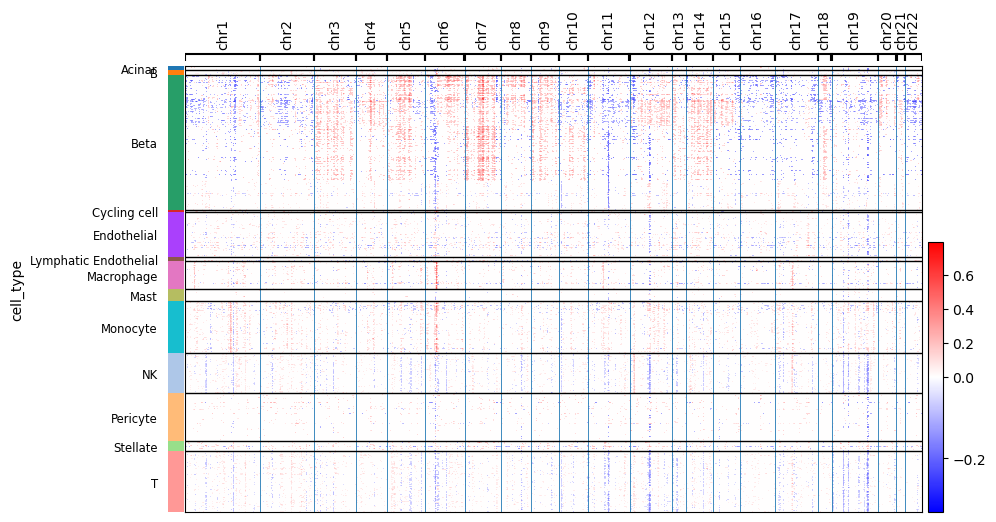

In [41]:
cnv.pl.chromosome_heatmap(
    adata_cnv,
    groupby="cell_type",
    figsize=(10, 6)
)

In [42]:
adata_cnv.obs["cnv_score"] = np.asarray(np.abs(adata_cnv.obsm["X_cnv"]).mean(axis=1)).ravel()

... storing 'chromosome' as categorical


<Figure size 900x300 with 0 Axes>

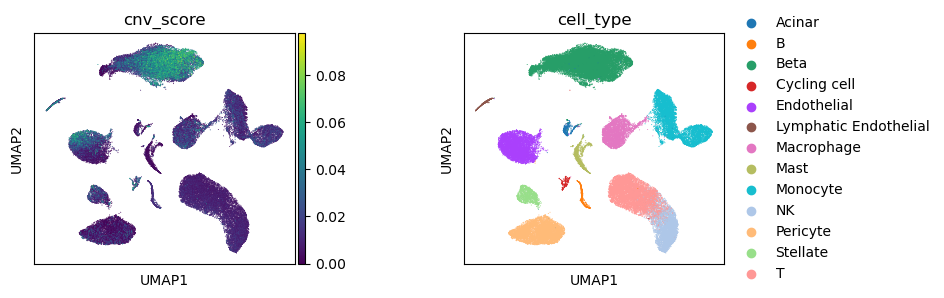

In [44]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_cnv,color=['cnv_score','cell_type'],wspace=0.5)

In [45]:
adata_cnv.write_h5ad("h5ad/adata_cnv.h5ad",compression='gzip')